# Part 1: Rig Operating Mode Prediction

## Objective

The objective of this section is to develop a machine learning model capable of predicting the operating mode of the drilling rig using sensor and operational measurements.

Rig operating mode represents the current operational state of the drilling system. Depending on the labels available in the dataset, these states may represent activities such as drilling, tripping, circulating, connection, or other rig operations.

Automatically identifying rig operating states can help in:

- Monitoring drilling operations
- Identifying operational patterns
- Measuring timestampstampstampstampstampstampstampstamp spent in different activities
- Supporting automated drilling analytics
- Detecting unexpected operational behaviour

Multiple classification algorithms will be evaluated, and the best-performing model will be selected.

In [92]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## 1. Load the cleaned drilling dataset

We begin with `drilling_data_cleaned.csv`, which is the **master cleaned dataset** created during the general data-cleaning stage.

General cleaning is kept separate from ROP-specific preprocessing so that the same master dataset can also be reused for other ML tasks.


In [93]:
#loading dataset
df = pd.read_csv(r"drilling_data_cleaned.csv") 

## 2. Initial dataset inspection

Before modeling, we inspect a few rows and check the dataset dimensions, data types, and available columns. This helps confirm that the expected drilling variables are present and that the dataset loaded correctly.


In [94]:
# inspecting the dataset
df.head()

,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,pump_pressure,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,day_of_week,timestamp
0,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
1,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
2,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
3,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
4,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00


In [95]:
df.shape

(598709, 37)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598709 entries, 0 to 598708
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   block_position           598664 non-null  float64
 1   weight_on_bit            598709 non-null  float64
 2   hookload                 598709 non-null  float64
 3   slips_set                598644 non-null  float64
 4   rop_depth_hour           598709 non-null  float64
 5   on_bottom                598665 non-null  float64
 6   top_drive_rpm            598709 non-null  float64
 7   top_drive_torque_ft_lbs  598664 non-null  float64
 8   flow_in                  598709 non-null  float64
 9   pump_pressure            598709 non-null  float64
 10  spm_total                598709 non-null  float64
 11  pit_volume_active        598709 non-null  float64
 12  pit_gl_active            598709 non-null  float64
 13  gas_total_units          552440 non-null  float64
 14  trip

In [97]:
df.columns.tolist()

['block_position',
 'weight_on_bit',
 'hookload',
 'slips_set',
 'rop_depth_hour',
 'on_bottom',
 'top_drive_rpm',
 'top_drive_torque_ft_lbs',
 'flow_in',
 'pump_pressure',
 'spm_total',
 'pit_volume_active',
 'pit_gl_active',
 'gas_total_units',
 'trip_volume_active',
 'trip_gl',
 'return_flow',
 'rig_mode',
 'rockit_on_off',
 'mwd_inclination',
 'mwd_azimuth',
 'mud_temp',
 'h2s_01',
 'rig_event_code',
 'total_depth',
 'bit_diameter',
 'bit_rpm',
 'depth_hole_tvd',
 'differential_pressure',
 'downhole_torque',
 'drill_mode',
 'year',
 'month',
 'day',
 'hour',
 'day_of_week',
 'timestamp']

## 3. Rig Mode Target Analysis

Before developing the classification models, the target variable `rig_mode` is examined.

Understanding the number and distribution of classes is important because highly imbalanced classes can make classification accuracy misleading.

The following analysis examines:

- Unique rig operating modes
- Number of classes
- Number of observations belonging to each class
- Percentage distribution of each class

In [98]:
print("Unique Rig Modes:")
print(df["rig_mode"].unique())

print("\nNumber of Rig Modes:")
print(df["rig_mode"].nunique())

print("\nRig Mode Distribution:")
print(df["rig_mode"].value_counts())

print("\nRig Mode Percentage:")
print(
    df["rig_mode"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Unique Rig Modes:
[  3.   1. 999.   2.  nan]

Number of Rig Modes:
4

Rig Mode Distribution:
rig_mode
3.0      243926
2.0      149314
1.0      103975
999.0    101466
Name: count, dtype: int64

Rig Mode Percentage:
rig_mode
3.0      40.74
2.0      24.94
1.0      17.37
999.0    16.95
Name: proportion, dtype: float64


## 4. Rig Mode Class Distribution

A bar chart is used to visualize the distribution of rig operating modes.

This visualization helps determine whether the classification problem contains balanced or imbalanced classes.

If one operating mode dominates the dataset, evaluation metrics such as Precision, Recall, and F1-Score become particularly important because Accuracy alone may provide a misleading assessment of model performance.

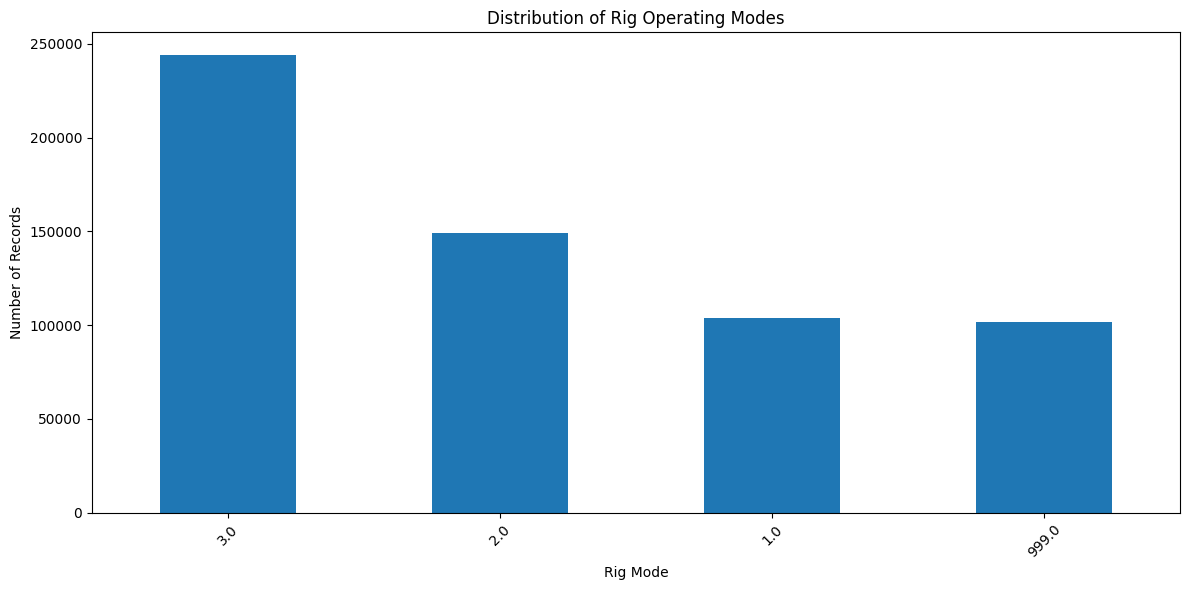

In [99]:
rig_counts = df["rig_mode"].value_counts()

plt.figure(figsize=(12, 6))
rig_counts.plot(kind="bar")

plt.title("Distribution of Rig Operating Modes")
plt.xlabel("Rig Mode")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Feature Selection

Relevant drilling sensor and operational parameters are selected as input features for predicting Rig Operating Mode.

The selected features represent mechanical, hydraulic, positional, and directional characteristics of the drilling operation.

Variables that could directly reveal the target, such as `rig_mode` itself or closely related event labels, are excluded to prevent **target leakage**.

Target leakage occurs when information that would not realistically be available during prediction indirectly reveals the correct target to the model, resulting in artificially high performance.

In [100]:
candidate_features = [
    "weight_on_bit",
    "hookload",
    "top_drive_rpm",
    "top_drive_torque_ft_lbs",
    "flow_in",
    "pump_pressure",
    "differential_pressure",
    "block_position",
    "total_depth",
    "bit_rpm",
    "mud_temp",
    "return_flow"
]

features = [
    col for col in candidate_features
    if col in df.columns
]

print("Features used:")
for feature in features:
    print("-", feature)

print("\nNumber of Features:", len(features))

Features used:
- weight_on_bit
- hookload
- top_drive_rpm
- top_drive_torque_ft_lbs
- flow_in
- pump_pressure
- differential_pressure
- block_position
- total_depth
- bit_rpm
- mud_temp
- return_flow

Number of Features: 12


In [101]:
X = df[features].copy()
y = df["rig_mode"].copy()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (598709, 12)
y Shape: (598709,)


In [102]:
print("Rows with at least one missing feature:",
      X.isnull().any(axis=1).sum())

print("Total rows:", len(X))

Rows with at least one missing feature: 77
Total rows: 598709


In [103]:
print("Rows before ML filtering:", len(df))

df_model = df.dropna(
    subset=features + ["rig_mode"]
).reset_index(drop=True)

print("Rows after ML filtering:", len(df_model))

print(
    "Remaining missing values:",
    df_model[features + ["rig_mode"]]
    .isnull()
    .sum()
    .sum()
)

Rows before ML filtering: 598709
Rows after ML filtering: 598628
Remaining missing values: 0


In [104]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", pd.isna(y).sum())

Missing values in X: 181
Missing values in y: 28


In [105]:
print(
    X.isnull()
     .sum()
     .loc[lambda x: x > 0]
     .sort_values(ascending=False)
)

mud_temp                   46
top_drive_torque_ft_lbs    45
differential_pressure      45
block_position             45
dtype: int64


## 6. Prepare the Modeling Dataset

A separate modeling DataFrame is created containing:

- Timestamp
- Selected input features
- Rig Mode target

The observations are sorted chronologically using the `time` column.

Sorting the dataset is necessary because drilling measurements are sequential. The model will later be trained using earlier observations and evaluated using later observations.

In [106]:
# Create modeling dataset
df_model = df[
    ["timestamp"] + features + ["rig_mode"]
].copy()

# Convert timestamp to proper datetime format
df_model["timestamp"] = pd.to_datetime(
    df_model["timestamp"],
    errors="coerce"
)

# Sort chronologically
df_model = (
    df_model
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Rows before filtering:", len(df_model))

# Remove rows missing any selected feature, timestamp, or target
df_model = df_model.dropna(
    subset=["timestamp"] + features + ["rig_mode"]
).reset_index(drop=True)

print("Rows after filtering:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Rows before filtering: 598709
Rows after filtering: 598628
Rows removed: 81


## 7. Final Missing Value Check

Although missing values were handled during the data cleaning phase, a final validation is performed before machine learning.

Machine learning algorithms generally require complete input data, and remaining missing values could prevent model training or affect prediction quality.

In [107]:
print("Missing Values in Features:")
print(df_model[features].isnull().sum())

print(
    "\nTotal Missing Feature Values:",
    df_model[features].isnull().sum().sum()
)

print(
    "Missing Target Values:",
    df_model["rig_mode"].isnull().sum()
)

Missing Values in Features:
weight_on_bit              0
hookload                   0
top_drive_rpm              0
top_drive_torque_ft_lbs    0
flow_in                    0
pump_pressure              0
differential_pressure      0
block_position             0
total_depth                0
bit_rpm                    0
mud_temp                   0
return_flow                0
dtype: int64

Total Missing Feature Values: 0
Missing Target Values: 0


In [108]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", pd.isna(y).sum())

Missing values in X: 181
Missing values in y: 28


## 8. Target Variable Encoding

The `rig_mode` variable contains categorical labels.

Most machine learning classification algorithms require the target variable to be represented numerically. Therefore, Label Encoding is applied to convert each Rig Mode category into an integer.

The mapping between the original Rig Mode labels and encoded values is retained so that model predictions can later be converted back into meaningful operating mode names.

In [109]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df_model["rig_mode"].astype(str)
)

X = df_model[features].copy()

class_mapping = pd.DataFrame({
    "Encoded_Value": range(len(label_encoder.classes_)),
    "Rig_Mode": label_encoder.classes_
})

class_mapping

,Encoded_Value,Rig_Mode
0,0,1.0
1,1,2.0
2,2,3.0
3,3,999.0


## 9. Chronological Train-Test Split

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

A chronological split is used instead of a random split.

Because drilling measurements are recorded sequentially over time, randomly mixing observations could place measurements from nearly identical time periods in both the training and testing datasets.

This could result in data leakage and overly optimistic model performance.

Therefore:

- Earlier observations are used for model training.
- Later observations are reserved for model testing.

This provides a more realistic evaluation of how the model performs on future drilling observations.

In [110]:
print("Total observations:", len(df_model))
print(
    "Unique timestamps:",
    df_model["timestamp"].nunique()
)

print(
    "Duplicate timestamps:",
    df_model["timestamp"].duplicated().sum()
)

print("\nObservations per timestamp:")
print(
    df_model["timestamp"]
    .value_counts()
    .describe()
)

Total observations: 598628
Unique timestamps: 1704
Duplicate timestamps: 596924

Observations per timestamp:
count    1704.000000
mean      351.307512
std        29.950702
min         7.000000
25%       354.000000
50%       358.000000
75%       359.000000
max       713.000000
Name: count, dtype: float64


In [111]:
# Initial 80% position
split_index = int(len(df_model) * 0.80)

# Timestamp corresponding to approximately 80% of the data
cutoff_time = df_model.loc[
    split_index,
    "timestamp"
]

# Ensure the same timestamp never appears
# in both training and testing datasets
train_mask = df_model["timestamp"] < cutoff_time
test_mask = df_model["timestamp"] >= cutoff_time

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Cutoff Time:", cutoff_time)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

print("\nTraining Percentage:")
print(
    round(
        len(X_train) / len(X) * 100,
        2
    ),
    "%"
)

print("\nTesting Percentage:")
print(
    round(
        len(X_test) / len(X) * 100,
        2
    ),
    "%"
)

Cutoff Time: 2020-12-22 03:00:00

Training Samples: 478751
Testing Samples : 119877

Training Percentage:
79.97 %

Testing Percentage:
20.03 %


## 10. Training and Testing Time Periods

The time ranges represented by the training and testing datasets are examined to verify that the chronological split has been performed correctly.

In [112]:
train_timestamps = df_model.loc[
    train_mask,
    "timestamp"
]

test_timestamps = df_model.loc[
    test_mask,
    "timestamp"
]

print(
    "Training Period:",
    train_timestamps.min(),
    "to",
    train_timestamps.max()
)

print(
    "\nTesting Period:",
    test_timestamps.min(),
    "to",
    test_timestamps.max()
)

print(
    "\nSame timestamp across boundary:",
    train_timestamps.max() >= test_timestamps.min()
)

Training Period: 2020-10-25 12:00:00 to 2020-12-22 02:00:00

Testing Period: 2020-12-22 03:00:00 to 2021-01-05 11:00:00

Same timestamp across boundary: False


## 11. Class Distribution in Training and Testing Data

Before training the models, the Rig Mode classes present in the training and testing datasets are examined.

For reliable model evaluation, operating modes present in the testing dataset should ideally also be represented in the training dataset.

If a Rig Mode appears only during the testing period, the model has never observed examples of that operating state during training and therefore cannot realistically learn how to identify it.

In [113]:
train_classes = np.unique(y_train)
test_classes = np.unique(y_test)

print("Classes in Training Set:")
print(
    label_encoder.inverse_transform(train_classes)
)

print("\nClasses in Testing Set:")
print(
    label_encoder.inverse_transform(test_classes)
)

unseen_test_classes = np.setdiff1d(
    test_classes,
    train_classes
)

if len(unseen_test_classes) == 0:
    print("\nAll testing classes are represented in training data.")
else:
    print("\nWARNING: Classes found in test but not training:")
    print(
        label_encoder.inverse_transform(
            unseen_test_classes
        )
    )

Classes in Training Set:
['1.0' '2.0' '3.0' '999.0']

Classes in Testing Set:
['1.0' '2.0' '3.0' '999.0']

All testing classes are represented in training data.


## 12. Feature Scaling

Feature scaling is not applied in this experiment.

The classification algorithms used in this notebook are tree-based models:

- Random Forest
- XGBoost
- LightGBM
- CatBoost

Tree-based algorithms divide observations using feature thresholds and are generally not sensitive to differences in feature magnitude.

Therefore, StandardScaler or MinMaxScaler is not required for these models.

## 13. Model Evaluation Function

A reusable evaluation function is created to ensure that every classification algorithm is evaluated using the same metrics.

The following metrics are calculated:

### Accuracy

Measures the proportion of total predictions that were correct.

### Precision

Measures how often predictions belonging to a particular class are correct.

### Recall

Measures how effectively the model identifies observations belonging to each class.

### F1-Score

Represents the harmonic mean of Precision and Recall.

Because Rig Mode classes may not be equally distributed, the **weighted F1-Score** will be used as an important metric when comparing models.

In [114]:
def evaluate_classifier(
    name,
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")

    result = {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1
    }

    return result, predictions


## 14. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees.

Each tree is trained using a different sample of the data and a subset of available features. The final classification is determined by combining the predictions of the individual trees.

Random Forest is included because it:

- Handles nonlinear relationships effectively
- Works well with large structured datasets
- Is relatively robust to noise
- Provides feature importance
- Can handle complex interactions between drilling parameters

Class weighting is enabled to reduce the effect of class imbalance.

In [115]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

rf_result, rf_predictions = evaluate_classifier(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)


Random Forest
Accuracy       : 0.7077
Precision      : 0.7123
Recall         : 0.7077
Weighted F1    : 0.7089
Macro F1       : 0.4771


## 15. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a boosting algorithm in which decision trees are constructed sequentially.

Each new tree attempts to correct errors made by the previous trees.

XGBoost is included because it:

- Performs strongly on structured/tabular datasets
- Captures complex nonlinear relationships
- Includes regularization mechanisms
- Can achieve high predictive performance

In [116]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_result, xgb_predictions = evaluate_classifier(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)


XGBoost
Accuracy       : 0.6494
Precision      : 0.6799
Recall         : 0.6494
Weighted F1    : 0.6562
Macro F1       : 0.4443


## 16. LightGBM Classifier

LightGBM (Light Gradient Boosting Machine) is an efficient gradient boosting algorithm designed for large datasets.

Unlike traditional level-wise tree growth, LightGBM uses a leaf-wise growth strategy that can improve predictive accuracy while maintaining computational efficiency.

LightGBM is particularly suitable for this project because the drilling dataset contains a large number of observations.

In [117]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_result, lgbm_predictions = evaluate_classifier(
    "LightGBM",
    lgbm_model,
    X_test,
    y_test
)


LightGBM
Accuracy       : 0.5735
Precision      : 0.6681
Recall         : 0.5735
Weighted F1    : 0.5908
Macro F1       : 0.4166


## 17. CatBoost Classifier

CatBoost is a gradient boosting algorithm designed to provide strong predictive performance while reducing overfitting.

It is particularly effective for structured datasets and can efficiently model complex nonlinear relationships.

CatBoost is included to provide another modern boosting algorithm for comparison with XGBoost and LightGBM.

In [118]:
cat_model = CatBoostClassifier(
    iterations=200,
    depth=8,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train,
    y_train
)

cat_result, cat_predictions = evaluate_classifier(
    "CatBoost",
    cat_model,
    X_test,
    y_test
)


CatBoost
Accuracy       : 0.6806
Precision      : 0.7033
Recall         : 0.6806
Weighted F1    : 0.6878
Macro F1       : 0.4611


### 17.1 Majority-Class Baseline

A majority-class baseline is evaluated to determine whether the
machine learning classifiers provide meaningful predictive improvement
over a naive strategy that always predicts the most frequent Rig Mode.

In [119]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_result, dummy_predictions = evaluate_classifier(
    "Majority Baseline",
    dummy_model,
    X_test,
    y_test
)


Majority Baseline
Accuracy       : 0.4990
Precision      : 0.2490
Recall         : 0.4990
Weighted F1    : 0.3323
Macro F1       : 0.1665


## 18. Classification Model Comparison

The performance of Random Forest, XGBoost, LightGBM, and CatBoost is compared using the same testing dataset.

The comparison considers:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-Score

The weighted F1-Score is used as the primary comparison metric because it considers both Precision and Recall while accounting for differences in class frequency.

The model achieving the strongest overall performance will be selected for detailed evaluation.

In [120]:
results = pd.DataFrame([
    dummy_result,
    rf_result,
    xgb_result,
    lgbm_result,
    cat_result
])

results = results.sort_values(
    "Weighted F1",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Random Forest,0.707734,0.712303,0.707734,0.708885,0.477110
1,CatBoost,0.680606,0.703316,0.680606,0.687770,0.461116
2,XGBoost,0.649391,0.679936,0.649391,0.656242,0.444300
3,LightGBM,0.573546,0.668146,0.573546,0.590799,0.416614
4,Majority Baseline,0.499028,0.249029,0.499028,0.332254,0.166451


## 19. Model Performance Visualization

The weighted F1-Score of each classification algorithm is visualized to provide a clear comparison of model performance.

Detailed diagnostic visualizations will only be generated for the best-performing model rather than creating repetitive plots for every candidate algorithm.

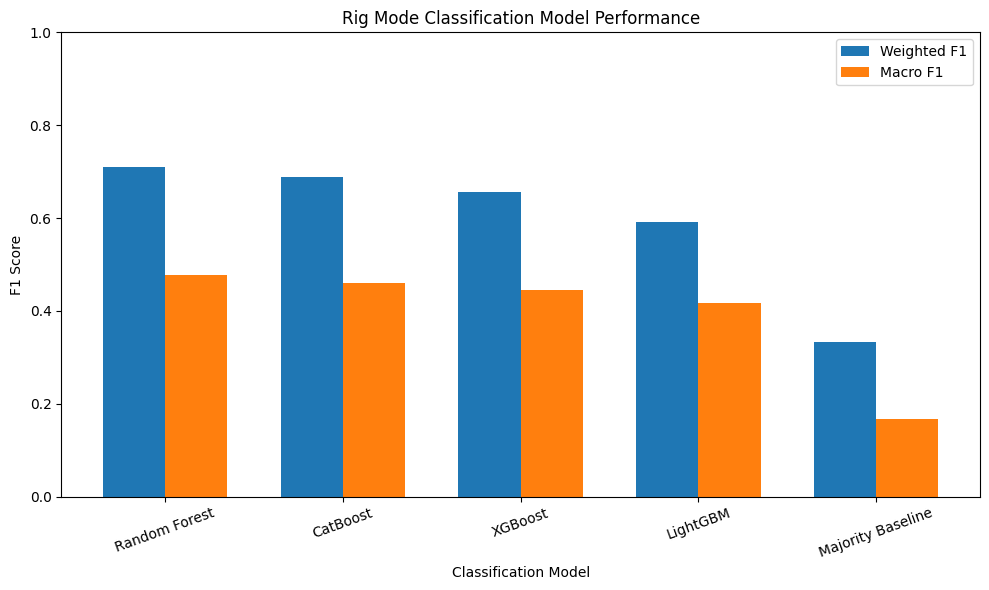

In [121]:
x = np.arange(len(results["Model"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    results["Weighted F1"],
    width,
    label="Weighted F1"
)

plt.bar(
    x + width/2,
    results["Macro F1"],
    width,
    label="Macro F1"
)

plt.xlabel("Classification Model")
plt.ylabel("F1 Score")

plt.title(
    "Rig Mode Classification Model Performance"
)

plt.xticks(
    x,
    results["Model"],
    rotation=20
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

## Class-Level Distribution Analysis

Because overall performance metrics can hide poor performance on
minority classes, the distribution of each Rig Operating Mode in the
training and testing periods is examined.

This analysis helps determine whether poor class-level performance
may be associated with class imbalance or temporal distribution changes.

In [122]:
train_labels = label_encoder.inverse_transform(
    y_train
)

test_labels = label_encoder.inverse_transform(
    y_test
)

train_distribution = pd.Series(
    train_labels
).value_counts().sort_index()

test_distribution = pd.Series(
    test_labels
).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Training Samples": train_distribution,
    "Testing Samples": test_distribution
}).fillna(0).astype(int)

class_distribution["Train %"] = (
    class_distribution["Training Samples"]
    / class_distribution["Training Samples"].sum()
    * 100
)

class_distribution["Test %"] = (
    class_distribution["Testing Samples"]
    / class_distribution["Testing Samples"].sum()
    * 100
)

class_distribution

,Training Samples,Testing Samples,Train %,Test %
1.0,101677,2298,21.237971,1.916965
2.0,108975,40339,22.762355,33.650325
3.0,184051,59822,38.443993,49.902817
999.0,84048,17418,17.555681,14.529893


## 20. Best Model Selection

The best-performing classifier is selected based primarily on the weighted F1-Score.

The selected model will undergo additional evaluation using:

- Classification Report
- Confusion Matrix
- Feature Importance

This approach ensures that detailed analysis focuses on the model that demonstrates the strongest predictive performance.

In [123]:
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

prediction_sets = {
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "LightGBM": lgbm_predictions,
    "CatBoost": cat_predictions
}

best_model_name = results.iloc[0]["Model"]

best_model = models[
    best_model_name
]

best_predictions = prediction_sets[
    best_model_name
]

print("Best Performing Model:")
print(best_model_name)

print(
    "\nWeighted F1 Score:",
    round(
        results.iloc[0]["Weighted F1"],
        4
    )
)

print(
    "Macro F1 Score:",
    round(
        results.iloc[0]["Macro F1"],
        4
    )
)

Best Performing Model:
Random Forest

Weighted F1 Score: 0.7089
Macro F1 Score: 0.4771


In [124]:
report = classification_report(
    y_test,
    best_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

classification_df = pd.DataFrame(
    report
).transpose()

classification_df

,precision,recall,f1-score,support
1.0,0.000000,0.000000,0.000000,2298.000000
2.0,0.700557,0.664469,0.682036,40339.000000
3.0,0.858422,0.844589,0.851449,59822.000000
999.0,0.331641,0.431278,0.374953,17418.000000
accuracy,0.707734,0.707734,0.707734,0.707734
macro avg,0.472655,0.485084,0.477110,119877.000000
weighted avg,0.712303,0.707734,0.708885,119877.000000


## 21. Detailed Classification Report

The Classification Report provides class-level performance metrics for the selected model.

For each Rig Operating Mode, the report presents:

- Precision
- Recall
- F1-Score
- Support

This analysis is important because strong overall accuracy does not necessarily mean that every Rig Mode is predicted equally well.

In [125]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00      2298
         2.0       0.70      0.66      0.68     40339
         3.0       0.86      0.84      0.85     59822
       999.0       0.33      0.43      0.37     17418

    accuracy                           0.71    119877
   macro avg       0.47      0.49      0.48    119877
weighted avg       0.71      0.71      0.71    119877



## 22. Confusion Matrix

A Confusion Matrix is generated to examine how the selected model classifies individual Rig Operating Modes.

Correct predictions appear along the diagonal of the matrix, while off-diagonal values represent misclassifications.

This visualization helps identify which operating modes are easily distinguished and which modes are frequently confused by the model.

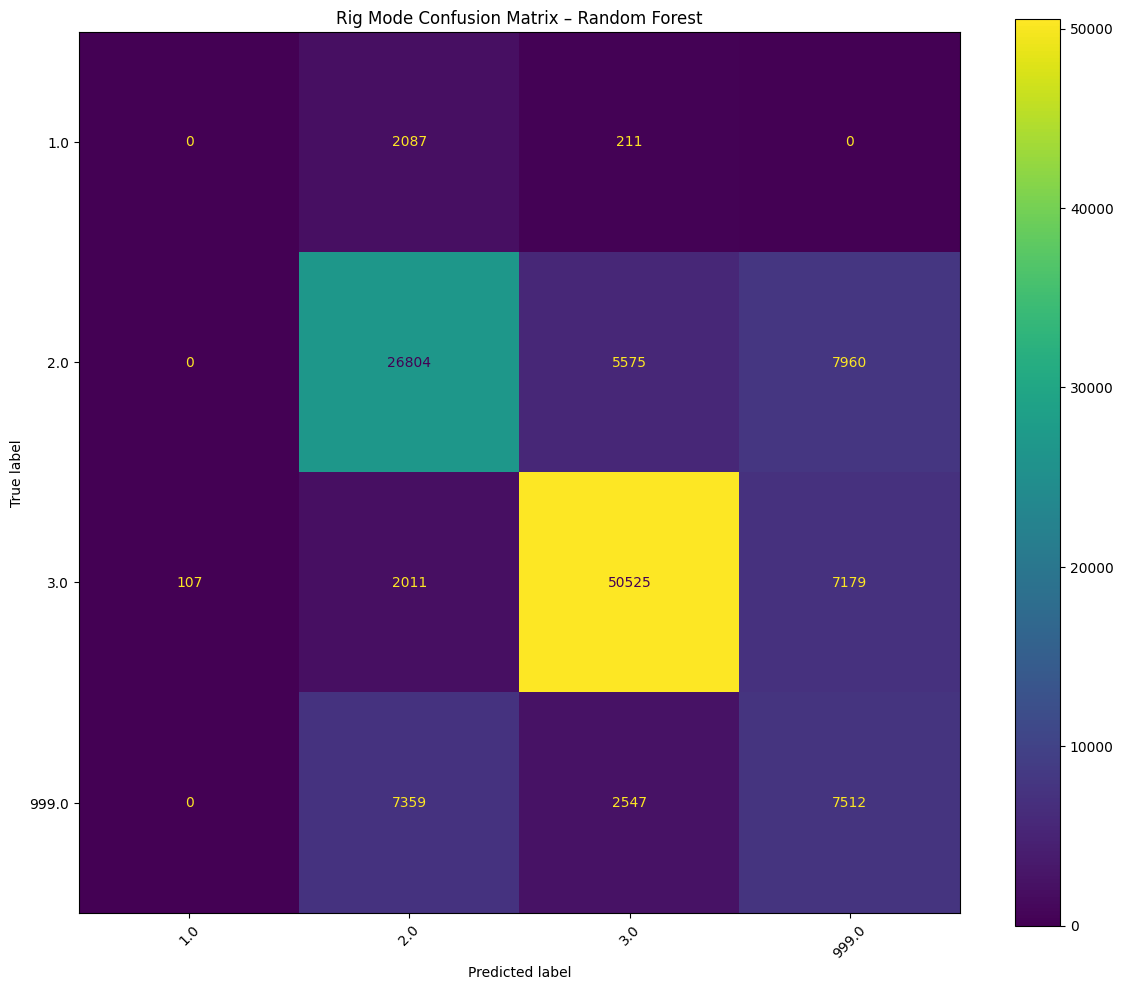

In [126]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    f"Rig Mode Confusion Matrix – {best_model_name}"
)

plt.tight_layout()
plt.show()

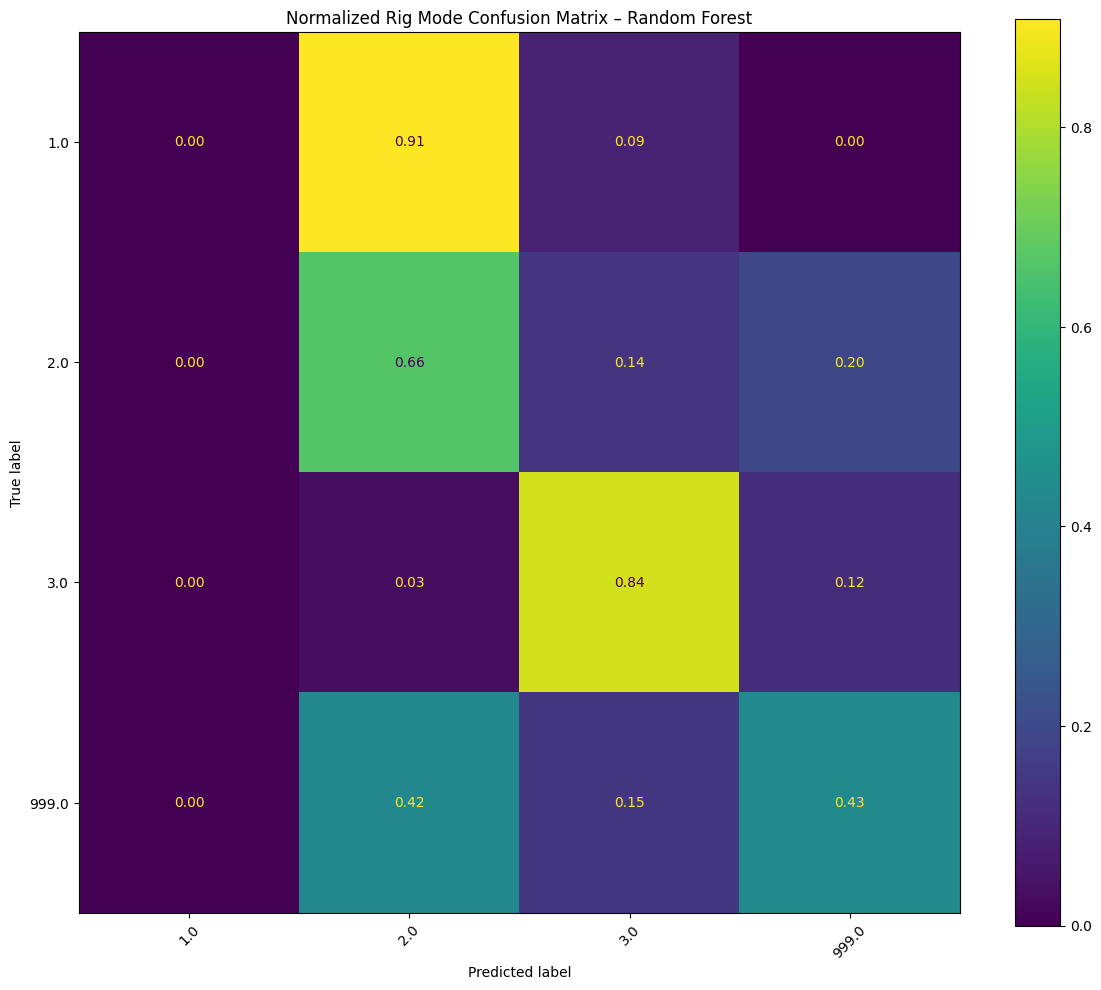

In [127]:
cm_normalized = confusion_matrix(
    y_test,
    best_predictions,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f"
)

plt.title(
    f"Normalized Rig Mode Confusion Matrix – {best_model_name}"
)

plt.tight_layout()
plt.show()

## 23. Feature Importance Analysis

Feature importance is examined to identify which drilling parameters
contribute most strongly to the selected model's Rig Operating Mode
predictions.

This analysis provides insight into the operational variables that
have the greatest influence on the classifier.

In [128]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

importance

,Feature,Importance
4,flow_in,0.033893
3,top_drive_torque_ft_lbs,0.048163
11,return_flow,0.052852
2,top_drive_rpm,0.063918
9,bit_rpm,0.065718
7,block_position,0.069023
5,pump_pressure,0.078793
10,mud_temp,0.097325
8,total_depth,0.104828
1,hookload,0.115878


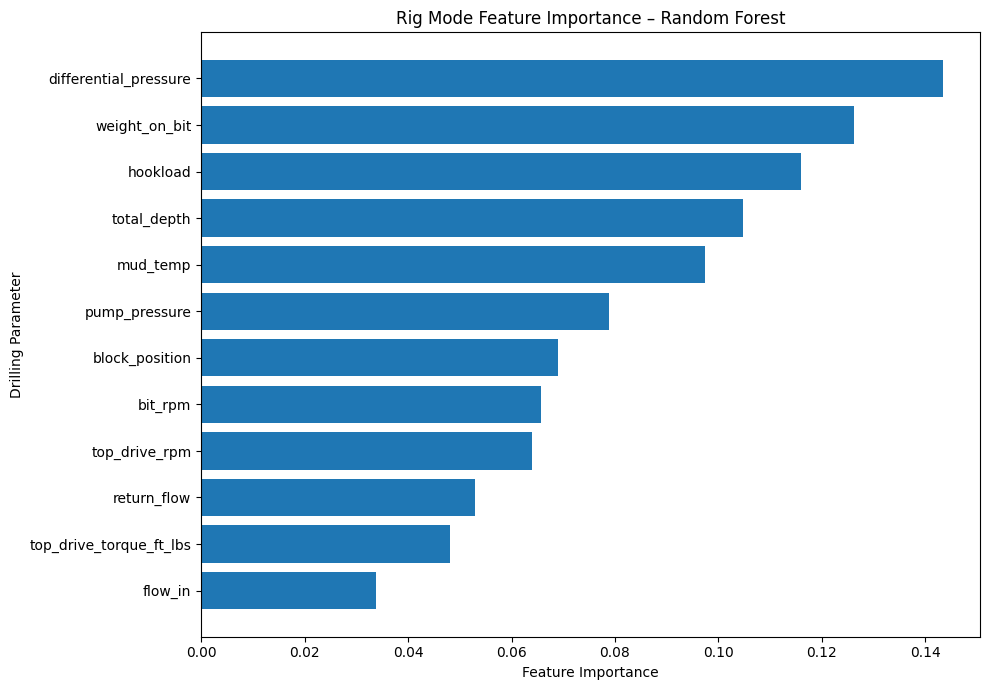

In [129]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Drilling Parameter")

plt.title(
    f"Rig Mode Feature Importance – {best_model_name}"
)

plt.tight_layout()
plt.show()

In [130]:
features_without_depth = [
    feature for feature in features
    if feature != "total_depth"
]

X_no_depth = df_model[
    features_without_depth
].copy()

X_train_no_depth = X_no_depth.loc[
    train_mask
]

X_test_no_depth = X_no_depth.loc[
    test_mask
]

rf_no_depth = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_no_depth.fit(
    X_train_no_depth,
    y_train
)

no_depth_predictions = rf_no_depth.predict(
    X_test_no_depth
)

print(
    classification_report(
        y_test,
        no_depth_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00      2298
         2.0       0.70      0.64      0.67     40339
         3.0       0.89      0.81      0.85     59822
       999.0       0.32      0.51      0.39     17418

    accuracy                           0.70    119877
   macro avg       0.48      0.49      0.48    119877
weighted avg       0.72      0.70      0.71    119877



## 24. Convert Predictions to Original Rig Mode Labels

The machine learning models generate encoded numerical predictions.

For practical interpretation and dashboard integration, these numerical predictions are converted back into their original Rig Operating Mode labels using the Label Encoder created earlier.

In [131]:
actual_labels = label_encoder.inverse_transform(
    y_test
)

predicted_labels = label_encoder.inverse_transform(
    best_predictions
)

prediction_results = pd.DataFrame({
    "time":
        df_model.loc[
            test_mask,
            "timestamp"
        ].values,

    "actual_rig_mode":
        actual_labels,

    "predicted_rig_mode":
        predicted_labels
})

print(
    "Prediction Result Rows:",
    len(prediction_results)
)

print(
    "Expected Test Rows:",
    len(y_test)
)

assert len(prediction_results) == len(y_test)

prediction_results.head(20)

Prediction Result Rows: 119877
Expected Test Rows: 119877


,time,actual_rig_mode,predicted_rig_mode
0,2020-12-22 03:00:00,999.0,2.0
1,2020-12-22 03:00:00,999.0,2.0
2,2020-12-22 03:00:00,999.0,2.0
3,2020-12-22 03:00:00,999.0,2.0
4,2020-12-22 03:00:00,999.0,2.0
5,2020-12-22 03:00:00,999.0,2.0
6,2020-12-22 03:00:00,999.0,2.0
7,2020-12-22 03:00:00,999.0,2.0
8,2020-12-22 03:00:00,999.0,2.0
9,2020-12-22 03:00:00,999.0,999.0


## 25. Identify Correct and Incorrect Predictions

A Boolean variable is created to indicate whether each Rig Mode prediction was correct.

This variable will be useful during Power BI analysis because it allows correct and incorrect predictions to be filtered, counted, and visualized over time.

In [132]:
prediction_results[
    "prediction_correct"
] = (
    prediction_results["actual_rig_mode"]
    ==
    prediction_results["predicted_rig_mode"]
)

prediction_results.head()

,time,actual_rig_mode,predicted_rig_mode,prediction_correct
0,2020-12-22 03:00:00,999.0,2.0,False
1,2020-12-22 03:00:00,999.0,2.0,False
2,2020-12-22 03:00:00,999.0,2.0,False
3,2020-12-22 03:00:00,999.0,2.0,False
4,2020-12-22 03:00:00,999.0,2.0,False


In [133]:
prediction_results[
    "prediction_correct"
].value_counts()

prediction_correct
True     84841
False    35036
Name: count, dtype: int64

## 26. Export Rig Mode Prediction Results

The final Rig Operating Mode prediction results are exported as a CSV file.

The exported dataset contains:

- Timestamp
- Actual Rig Mode
- Predicted Rig Mode
- Prediction correctness

This file will later be integrated with PostgreSQL and used for visualization in the Power BI dashboard.

In [134]:
prediction_results.to_csv(
    "rig_mode_predictions.csv",
    index=False
)

print(
    "Rig Mode predictions exported successfully."
)

Rig Mode predictions exported successfully.


## 27. Model Serialization

After evaluating the classification models and selecting the best-performing model, the trained components are saved for future use.

The following objects are serialized:

* **Best Classification Model** – the selected model used to predict Rig Operating Mode.
* **Label Encoder** – preserves the mapping between encoded class values and the original Rig Mode codes.
* **Feature List** – stores the exact drilling parameters required by the trained model.

Saving these components ensures that future predictions can be generated without retraining the model from scratch and that the same feature configuration and target encoding used during training are preserved.

The serialized artifacts can later be loaded into a prediction pipeline, application backend, or deployment environment for inference on new drilling data.


In [135]:
import joblib
import os

# Create models directory
os.makedirs("models", exist_ok=True)

# Save best Rig Mode model
joblib.dump(
    best_model,
    "models/rig_mode_classifier.pkl"
)

# Save Label Encoder
joblib.dump(
    label_encoder,
    "models/rig_mode_label_encoder.pkl"
)

print("Model and Label Encoder saved successfully.")

Model and Label Encoder saved successfully.


In [136]:
joblib.dump(
    features,
    "models/rig_mode_features.pkl"
)

['models/rig_mode_features.pkl']

In [137]:
loaded_model = joblib.load(
    "models/rig_mode_classifier.pkl"
)

loaded_encoder = joblib.load(
    "models/rig_mode_label_encoder.pkl"
)

loaded_features = joblib.load(
    "models/rig_mode_features.pkl"
)

# Test prediction
sample = X_test.iloc[[0]]

prediction_encoded = loaded_model.predict(sample)

prediction_label = loaded_encoder.inverse_transform(
    prediction_encoded.astype(int)
)

print("Encoded Prediction:", prediction_encoded[0])
print("Predicted Rig Mode:", prediction_label[0])

Encoded Prediction: 1
Predicted Rig Mode: 2.0


## 28. Rig Mode `999` Investigation

During exploratory analysis of the target variable, Rig Mode code `999` appears frequently in the dataset. Since values such as `999` are sometimes used in industrial datasets to represent unknown, unavailable, or special conditions, it should not automatically be treated as a valid operating state without further investigation.

To examine whether code `999` behaves like a meaningful recurring category, its frequency and associated drilling sensor characteristics are analyzed.

The investigation focuses on parameters such as:

* Weight on Bit
* Top Drive RPM
* Pump Pressure
* Flow In
* Hookload
* Top Drive Torque
* Differential Pressure
* Block Position

The objective is to determine whether observations labelled `999` exhibit a consistent operational sensor profile that differs from the other Rig Mode classes.

This analysis does **not** attempt to assign an engineering meaning to code `999`. Instead, it evaluates whether the available data provides sufficient evidence to retain it as a separate classification category rather than automatically treating it as a missing or invalid value.


In [138]:
print("Rig Mode Classes:")
print(label_encoder.classes_)

print("\nRig Mode Distribution:")
print(df_model["rig_mode"].value_counts().sort_index())

Rig Mode Classes:
['1.0' '2.0' '3.0' '999.0']

Rig Mode Distribution:
rig_mode
1.0      103975
2.0      149314
3.0      243873
999.0    101466
Name: count, dtype: int64


In [139]:
rig_999 = df[df["rig_mode"] == 999.0]

rig_999[
    [
        "weight_on_bit",
        "top_drive_rpm",
        "pump_pressure",
        "flow_in",
        "hookload",
        "block_position"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
weight_on_bit,101466.0,156.771269,56.530035,0.0000,145.236795,177.188510,186.509950,247.03064
top_drive_rpm,101466.0,3.005540,11.061682,0.0000,0.130680,0.231310,0.331940,89.45209
pump_pressure,101466.0,446.696941,1829.794518,0.0000,4.888420,9.333920,43.901815,10860.39100
flow_in,101466.0,69.937955,776.453838,0.0000,0.000000,0.000000,51.890010,125867.84000
hookload,101466.0,55.356089,39.438942,3.5403,40.132400,42.307450,46.060490,283.26938
block_position,101466.0,55.640306,34.677120,-19.4539,22.428960,55.668465,89.374290,116.24767


## 29. Interpretation of Rig Mode Codes

The Rig Operating Mode target contains four observed codes:

* `1`
* `2`
* `3`
* `999`

The original numerical codes are preserved throughout the classification workflow rather than being replaced with assumed operational descriptions.

Analysis of code `999` shows that it occurs repeatedly in the dataset and is associated with identifiable patterns across several drilling parameters. Based on the available data, it is therefore retained as a separate target class instead of being removed as a conventional missing value.

However, statistical differences between classes do not establish their precise engineering meanings. Without supporting metadata, data dictionaries, or domain documentation, assigning labels such as *Drilling*, *Connection*, *Tripping*, or *Idle* to these numerical codes would introduce unsupported assumptions.

Therefore, the model predicts the original Rig Mode codes directly. Their operational interpretation should be confirmed separately using authoritative dataset documentation or domain expertise.

This approach preserves the integrity of the original target variable while avoiding unsupported engineering assumptions.


In [140]:
rig_mode_comparison = df.groupby("rig_mode")[
    [
        "weight_on_bit",
        "top_drive_rpm",
        "pump_pressure",
        "flow_in",
        "hookload",
        "top_drive_torque_ft_lbs",
        "differential_pressure",
        "block_position"
    ]
].median()

rig_mode_comparison

,weight_on_bit,top_drive_rpm,pump_pressure,flow_in,hookload,top_drive_torque_ft_lbs,differential_pressure,block_position
rig_mode,,,,,,,,
1.0,40.812270,41.65165,2678.21730,596.72400,170.16655,4127.416,167.102170,51.323930
2.0,124.701955,0.27156,38.78017,62.38926,45.63401,0.000,-809.467525,51.350980
3.0,82.418360,0.29169,8.73072,0.00000,124.49040,0.000,-810.479060,24.549370
999.0,177.188510,0.23131,9.33392,0.00000,42.30745,0.000,-1459.897650,55.668465


# 30. Final Conclusion

This notebook developed and evaluated a machine learning classification pipeline for predicting **Rig Operating Mode** from drilling sensor and operational parameters.

The workflow began by examining the Rig Mode target distribution and selecting relevant drilling features while excluding variables that could introduce direct or indirect target leakage. The timestamp variable was converted to a proper datetime representation, and the dataset was arranged chronologically before model development.

To provide a realistic evaluation of future observations, a **chronological train-test split** was used instead of a random split. The split was performed at the timestamp level so that observations associated with the same timestamp were not distributed across both the training and testing datasets.

Multiple classification algorithms were evaluated, including:

* Random Forest
* XGBoost
* LightGBM
* CatBoost

A majority-class baseline was also included to determine whether the machine learning models provide meaningful predictive improvement over a naive strategy.

Model performance was evaluated using **Accuracy, Weighted Precision, Weighted Recall, Weighted F1-Score, and Macro F1-Score**. Weighted F1 provides an overall performance measure while accounting for class frequency, whereas Macro F1 gives equal importance to each Rig Mode class and therefore helps identify poor performance on less frequent operating states.

The best-performing model was selected primarily according to its Weighted F1-Score and was subsequently examined using a detailed classification report, class-level metrics, raw and normalized confusion matrices, and feature importance analysis.

The class-level evaluation is particularly important because overall classification performance does not necessarily indicate consistent performance across every Rig Mode. Differences in class-level Precision, Recall, and F1-Score may result from class imbalance, overlapping sensor behaviour, temporal changes in operating conditions, or limitations in the available predictor variables.

Additional investigation was performed for Rig Mode code `999`. The code occurs frequently and exhibits identifiable patterns across multiple drilling parameters. It was therefore retained as a separate classification category. However, no specific engineering interpretation was assigned to this code because its exact operational meaning cannot be established from the available data alone.

Finally, predictions were converted back to the original Rig Mode codes and exported for downstream analysis. The selected model, label encoder, and feature configuration were also serialized to support reproducibility and future deployment.

Overall, the developed pipeline provides a structured foundation for **automated Rig Operating Mode classification from drilling data**. At the same time, the class-level evaluation highlights opportunities for further improvement through temporal validation, class-imbalance handling, feature engineering, hyperparameter optimization, and validation using additional drilling operations or wells.
